In [1]:
import scarf

scarf.set_verbosity('WARNING')

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    'tenx_8K_pbmc_citeseq',
    destination='scarf_datasets',
    zarr=True,
)

In [2]:
ds = scarf.DataStore(
    f'{dataset}/data.zarr',
    default_assay='RNA',
    nthreads=4
)
ds

DataStore has 7549 (7865) cells with 2 assays: ADT RNA
   Cell metadata:
            'I', 'ids', 'names', 'ADT_UMAP2', 'RNA_percentMito', 
            'ADT_nFeatures', 'ADT_UMAP1', 'RNA_tSNE2', 'RNA_tSNE1', 'RNA_percentRibo', 
            'ADT_nCounts', 'RNA_nFeatures', 'RNA_UMAP2', 'RNA_leiden_cluster', 'RNA_nCounts', 
            'RNA_cluster', 'ADT_leiden_cluster', 'RNA_UMAP1'
   ADT assay has 14 (17) features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'nCells', 
          
   RNA assay has 13550 (33538) features and following metadata:
            'I', 'ids', 'names', 'I__hvgs', 'dropOuts', 
            'nCells'

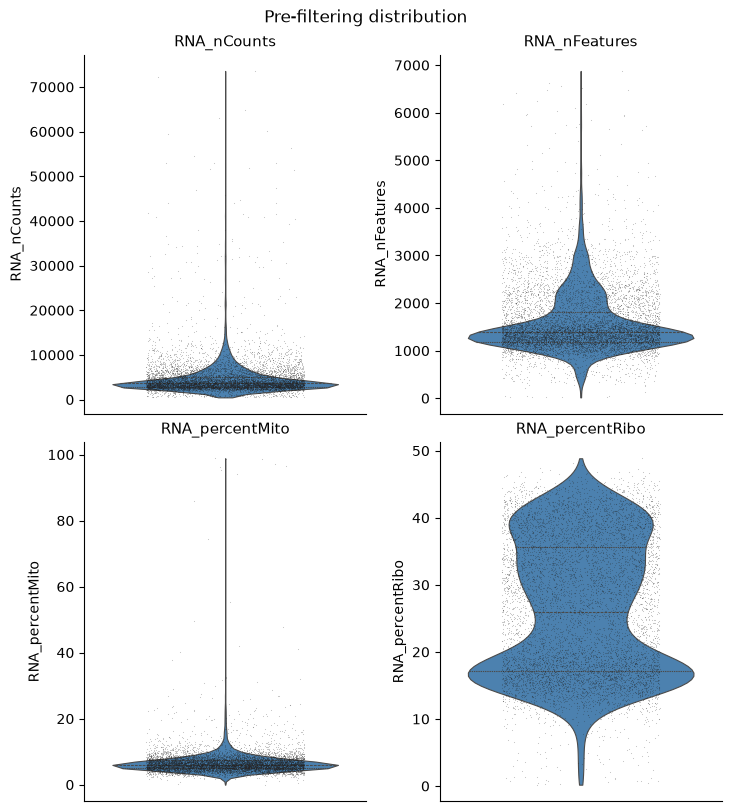

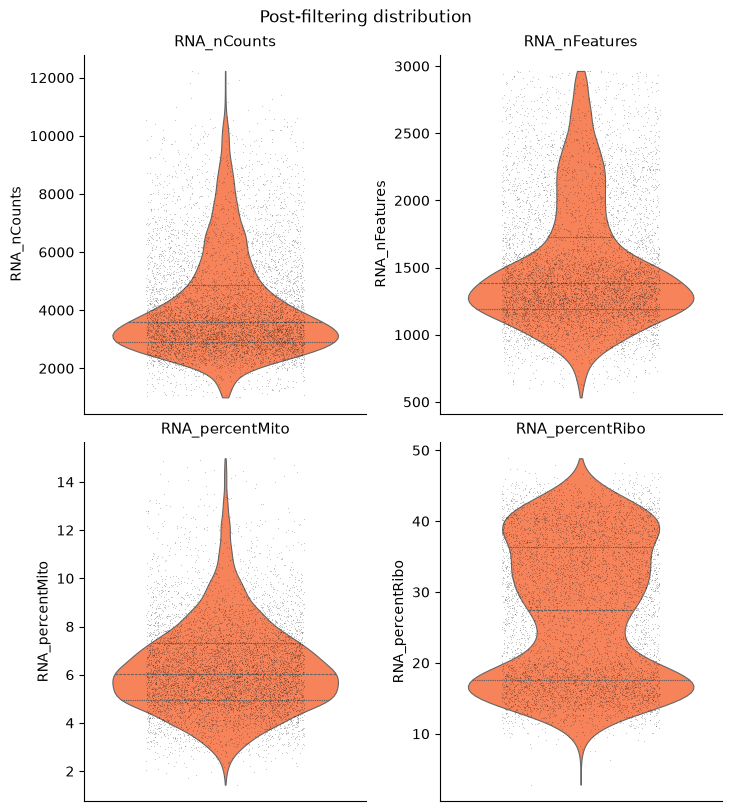

In [3]:
ds.auto_filter_cells()

In [4]:
ds.mark_hvgs(
    min_cells=20,
    top_n=1000,
    min_mean=-3,
    max_mean=2,
    max_var=6,
    show_plot=False,
)

ds.run_normalization(feat_key='hvgs')
ds.run_pca(dims=15)
ds.build_embedding_initialization()
ds.build_ann_index()
ds.query_neighbors(k=21)
ds.build_connectivity_map()

ds.run_umap(
    n_epochs=250,
    spread=5,
    min_dist=1,
    parallel=True
)
ds.run_leiden_clustering(resolution=1)
ds.load_graph()

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 154182 stored elements and shape (7342, 7342)>

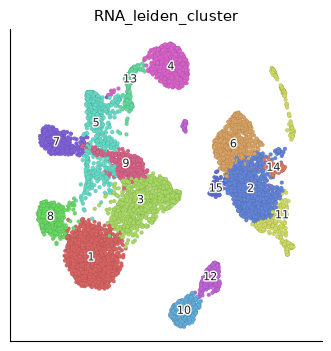

In [5]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='RNA_leiden_cluster',
)

In [6]:
ds.ADT.normMethod.__name__

'norm_clr'

In [7]:
adt_panel = ds.ADT.feats.to_pandas_dataframe(['names'])
adt_panel['is_control'] = adt_panel['names'].str.contains('control')
adt_panel

,names,is_control
0,CD3_TotalSeqB,False
1,CD4_TotalSeqB,False
2,CD8a_TotalSeqB,False
3,CD14_TotalSeqB,False
4,CD15_TotalSeqB,False
5,CD16_TotalSeqB,False
6,CD56_TotalSeqB,False
7,CD19_TotalSeqB,False
8,CD25_TotalSeqB,False
9,CD45RA_TotalSeqB,False


In [8]:
ds.ADT.feats.update_key(~adt_panel['is_control'].values, 'I')
print(
    f"Active ADT features: {int(ds.ADT.feats.fetch_all('I').sum())}"
    f" of {len(adt_panel)}"
)

Active ADT features: 14 of 17


In [9]:
ds.run_normalization(from_assay='ADT', feat_key='I')
ds.run_pca(from_assay='ADT', dims=0)
ds.build_embedding_initialization(from_assay='ADT', n_centroids=100)
ds.build_ann_index(from_assay='ADT')
ds.query_neighbors(from_assay='ADT', k=21)
ds.build_connectivity_map(from_assay='ADT')
ds.load_graph(from_assay='ADT')

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 154182 stored elements and shape (7342, 7342)>

In [10]:
ds.run_umap(
    from_assay='ADT',
    n_epochs=250,
    spread=5,
    min_dist=1,
    parallel=True
)
ds.run_leiden_clustering(
    from_assay='ADT',
    resolution=1
)
sorted(c for c in ds.cells.columns if c.startswith('ADT_'))

['ADT_UMAP1',
 'ADT_UMAP2',
 'ADT_leiden_cluster',
 'ADT_nCounts',
 'ADT_nFeatures']

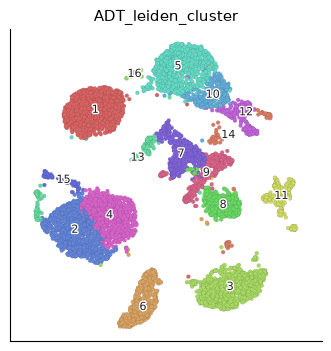

In [11]:
ds.plots.embedding(
    layout_key='ADT_UMAP',
    color_by='ADT_leiden_cluster',
)

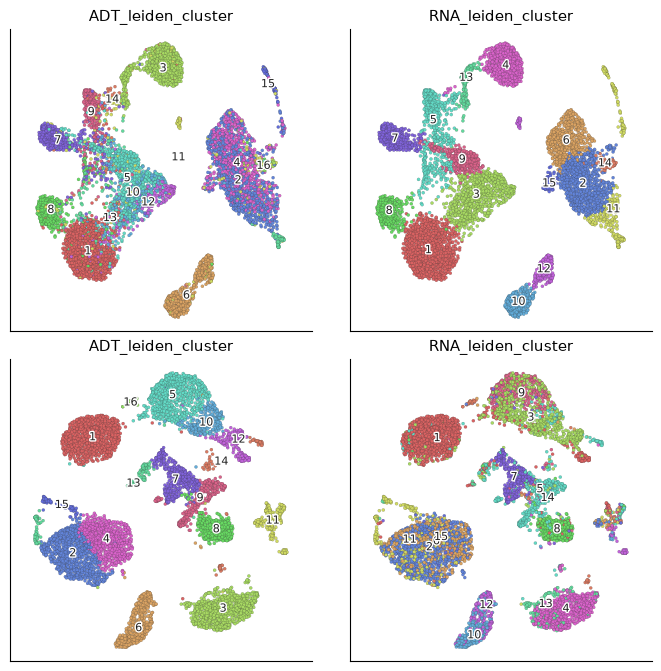

In [12]:
ds.plots.embedding(
    layout_key=['RNA_UMAP', 'ADT_UMAP'],
    color_by=['ADT_leiden_cluster', 'RNA_leiden_cluster'],
    n_columns=2,
    point_size=5,
    legend_loc='on_data',
)

In [13]:
import pandas as pd

overlap = pd.crosstab(
    ds.cells.fetch('RNA_leiden_cluster'),
    ds.cells.fetch('ADT_leiden_cluster')
)
overlap

col_0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
row_0,,,,,,,,,,,,,,,,
1,1027,0,0,0,48,0,6,24,0,14,18,64,26,2,0,0
2,0,483,0,403,0,2,0,0,2,2,28,1,0,0,0,3
3,25,0,0,0,427,0,12,2,10,220,15,142,9,5,0,0
4,0,0,711,0,0,0,1,0,1,0,24,0,0,13,0,0
5,18,0,2,0,15,1,77,37,295,43,35,2,37,40,0,0
6,0,252,0,319,1,0,0,2,0,1,17,1,1,0,0,4
7,0,0,0,0,19,0,395,5,1,0,12,0,1,2,0,0
8,6,0,0,0,0,0,5,344,6,0,4,0,8,3,0,0
9,1,0,0,0,290,0,7,1,2,13,15,1,9,7,0,0


In [14]:
(100 * overlap.max() / overlap.sum()).round(1).sort_values(ascending=False)

col_0
1     95.4
15    94.6
9     91.9
3     80.9
8     80.4
7     77.5
16    75.0
10    74.6
12    67.0
6     61.1
2     54.4
5     53.0
14    52.6
4     49.9
13    35.5
11    17.3
dtype: float64

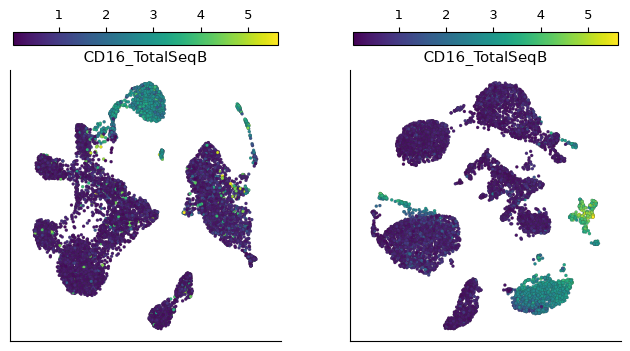

In [15]:
ds.plots.embedding(
    layout_key=['RNA_UMAP', 'ADT_UMAP'],
    color_by='CD16_TotalSeqB',
    from_assay='ADT',
    n_columns=2,
    point_size=5,
)

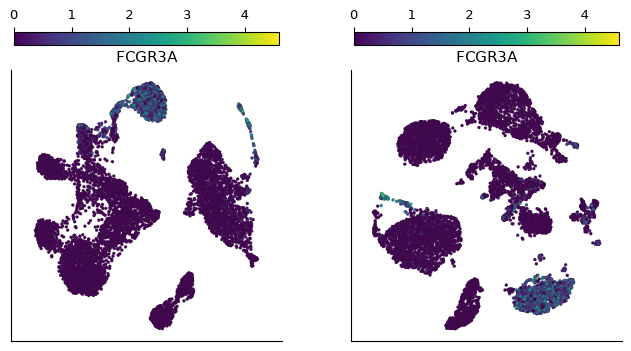

In [16]:
ds.plots.embedding(
    layout_key=['RNA_UMAP', 'ADT_UMAP'],
    color_by='FCGR3A',
    from_assay='RNA',
    n_columns=2,
    point_size=5,
)

In [17]:
ds.integrate_assays(
    assays=['RNA', 'ADT'],
    label='RNA+ADT',
    method='snn',
)

In [18]:
ds.run_umap(
    integrated_graph='RNA+ADT',
    n_epochs=500,
    spread=5,
    min_dist=0.5,
    parallel=True
)
ds.run_leiden_clustering(
    integrated_graph='RNA+ADT',
    resolution=1.75
)
sorted(c for c in ds.cells.columns if c.startswith('RNA+ADT'))

['RNA+ADT_UMAP1', 'RNA+ADT_UMAP2', 'RNA+ADT_leiden_cluster']

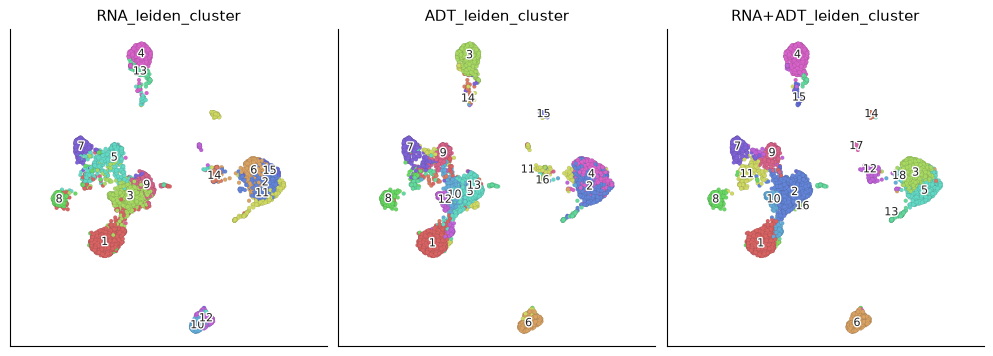

In [19]:
ds.plots.embedding(
    layout_key='RNA+ADT_UMAP',
    color_by=[
        'RNA_leiden_cluster',
        'ADT_leiden_cluster',
        'RNA+ADT_leiden_cluster',
    ],
    legend_loc='on_data',
    n_columns=3,
)

In [20]:
ds.integrate_assays(
    assays=['RNA', 'ADT'],
    label='RNA+ADT_wnn',
    method='wnn'
)
ds.run_umap(
    integrated_graph='RNA+ADT_wnn',
    n_epochs=500,
    spread=5,
    min_dist=0.5,
    parallel=True
)
ds.run_leiden_clustering(
    integrated_graph='RNA+ADT_wnn',
    resolution=1.75
)

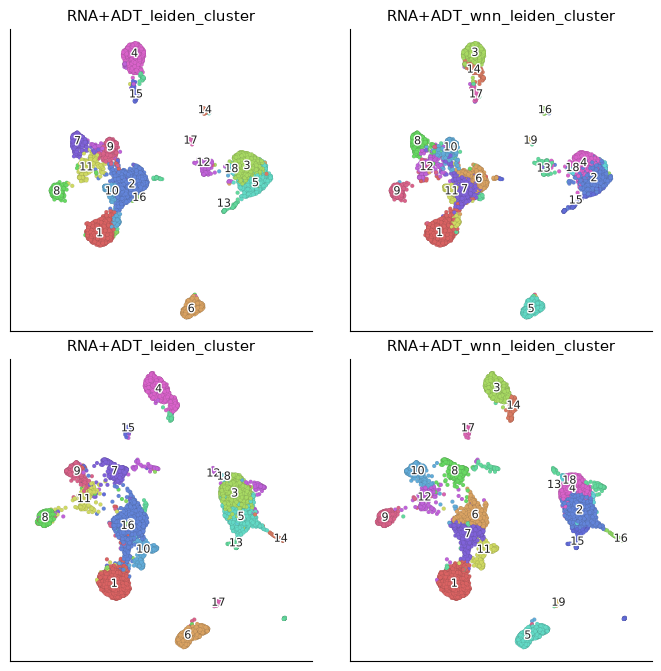

In [21]:
ds.plots.embedding(
    layout_key=['RNA+ADT_UMAP', 'RNA+ADT_wnn_UMAP'],
    color_by=['RNA+ADT_leiden_cluster', 'RNA+ADT_wnn_leiden_cluster'],
    n_columns=2,
    legend_loc='on_data',
)